# Prakruti Chatbot — Random Forest Model Training

Train a single Random Forest classifier for the `Dosha` target in `Data.csv`.

**ML output:** dominant Dosha class.

**Important:** Random Forest probabilities are not Vata/Pitta/Kapha percentages. Those percentages belong to the separate rule-based scoring component.


## 1. Imports


In [1]:
import json
import platform
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


In [39]:
from pathlib import Path
import joblib
import json

# Project root
PROJECT_ROOT = Path("..").resolve().parent

# Store all ML models and metadata inside ml/models
MODEL_DIR = PROJECT_ROOT / "ml" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# File paths
MODEL_PATH = MODEL_DIR / "prakruti_random_forest.pkl"
METADATA_PATH = MODEL_DIR / "prakruti_random_forest_metadata.json"

# Save trained model
joblib.dump(final_model, MODEL_PATH)

print("Model saved:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

# Metadata
metadata = {
    "model": "Random Forest",
    "model_file": MODEL_PATH.name,
    "target_column": "Dosha",
    "n_estimators": 300,
    "random_state": 42
}

# Save metadata
with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved:", METADATA_PATH)
print("Metadata exists:", METADATA_PATH.exists())

Model saved: D:\prakruti-chatbot\ml\models\prakruti_random_forest.pkl
Model exists: True
Metadata saved: D:\prakruti-chatbot\ml\models\prakruti_random_forest_metadata.json
Metadata exists: True


## 3. Load dataset


In [40]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Data.csv not found at {DATA_PATH}. "
        "Place it in data/raw/Data.csv or change DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1200, 30)


,Body Size,Body Weight,Height,Bone Structure,Complexion,General feel of skin,Texture of Skin,Hair Color,Appearance of Hair,Shape of face,...,Dosha,Metabolism Type,Climate Preference,Stress Levels,Sleep Patterns,Dietary Habits,Physical Activity Level,Water Intake,Digestion Quality,Skin Sensitivity
0,Medium,Moderate - no difficulties in gaining or losin...,Average,"Large, broad shoulders , heavy bone structure","White, pale, tans easily","Dry and thin, cool to touch, rough","Dry, pigments and aging","Black/Brown,dull","Straight, oily","Long, angular, thin",...,vata+pitta,fast,warm,moderate,moderate,vegan,moderate,moderate,moderate,sensitive
1,Medium,Moderate - no difficulties in gaining or losin...,Short,Medium bone structure,Fair-skin sunburns easily,"Dry and thin, cool to touch, rough",Oily,"Red, light brown, yellow","Dry, black, knotted, brittle","Long, angular, thin",...,vata+pitta,moderate,cool,moderate,moderate,vegetarian,sedentary,high,moderate,normal
2,Slim,Moderate - no difficulties in gaining or losin...,Average,Medium bone structure,Fair-skin sunburns easily,"Smooth and warm, oily T-zone",Oily,"Black/Brown,dull","Dry, black, knotted, brittle","Long, angular, thin",...,Pitta,fast,warm,moderate,short,omnivorous,moderate,moderate,moderate,normal
3,Slim,Moderate - no difficulties in gaining or losin...,Short,"Light, Small bones, prominent joints",Fair-skin sunburns easily,"Dry and thin, cool to touch, rough",Oily,"Black/Brown,dull","Straight, oily","Large, round, full",...,vata+pitta,slow,moderate,low,long,omnivorous,sedentary,moderate,strong,normal
4,Large,Moderate - no difficulties in gaining or losin...,Short,Medium bone structure,"Dark-Complexion, tans easily","Smooth and warm, oily T-zone",Oily,"Black/Brown,dull","Dry, black, knotted, brittle","Long, angular, thin",...,vata+pitta,slow,cool,low,moderate,omnivorous,moderate,moderate,weak,normal


## 4. Basic training checks

These are not a separate cleaning phase. They only verify that the notebook is training on the expected target and data structure.


In [41]:
TARGET_COLUMN = "Dosha"

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COLUMN}' was not found. "
        f"Available columns: {list(df.columns)}"
    )

print("Target:", TARGET_COLUMN)
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values").query("missing_values > 0"))

print("\nExact duplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df[TARGET_COLUMN].value_counts().to_frame("count"))


Target: Dosha
Rows: 1200
Columns: 30

Missing values:


,missing_values



Exact duplicate rows: 1

Target distribution:


,count
Dosha,
vata+pitta,624
Vata,264
Pitta,144
Kapha,72
pitta+kapha,48
vata+kapha,48


## 5. Remove exact duplicate rows

The dataset contains an exact duplicate record. Remove exact duplicates so the same record is not counted more than once.

No imputation is used because the dataset has categorical features and no missing values.


In [42]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Duplicates removed:", rows_before - rows_after)


Rows before: 1200
Rows after: 1199
Duplicates removed: 1


## 6. Define features and target


In [43]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("Number of input features:", X.shape[1])
print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

if numerical_features:
    raise ValueError(
        f"Unexpected numerical features found: {numerical_features}"
    )


Number of input features: 29
Categorical features: 29
Numerical features: 0


C:\Users\kakar\AppData\Local\Temp\ipykernel_8508\45472574.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


## 7. Stratified train/test split

Use 80% for training and 20% for testing while preserving the six-class target distribution.


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 959
Testing samples: 240


## 8. One-Hot Encoding

All questionnaire inputs are categorical. `handle_unknown="ignore"` makes the saved pipeline safer for FastAPI inference.


In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        )
    ],
    remainder="drop",
)


## 9. Random Forest model


In [46]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model),
    ]
)

model_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the 

## 10. Train the model


In [47]:
model_pipeline.fit(X_train, y_train)
print("Random Forest training completed.")


Random Forest training completed.


## 11. Test-set evaluation


In [48]:
y_pred = model_pipeline.predict(X_test)

test_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Macro Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
}

display(
    pd.DataFrame(
        {"Metric": list(test_metrics.keys()), "Score": list(test_metrics.values())}
    ).style.format({"Score": "{:.4f}"})
)


,Metric,Score
0,Accuracy,1.0000
1,Macro Precision,1.0000
2,Macro Recall,1.0000
3,Macro F1,1.0000


## 12. Classification report


In [49]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0,
    )
)


              precision    recall  f1-score   support

       Kapha       1.00      1.00      1.00        14
       Pitta       1.00      1.00      1.00        29
        Vata       1.00      1.00      1.00        53
 pitta+kapha       1.00      1.00      1.00        10
  vata+kapha       1.00      1.00      1.00         9
  vata+pitta       1.00      1.00      1.00       125

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



## 13. Confusion matrix


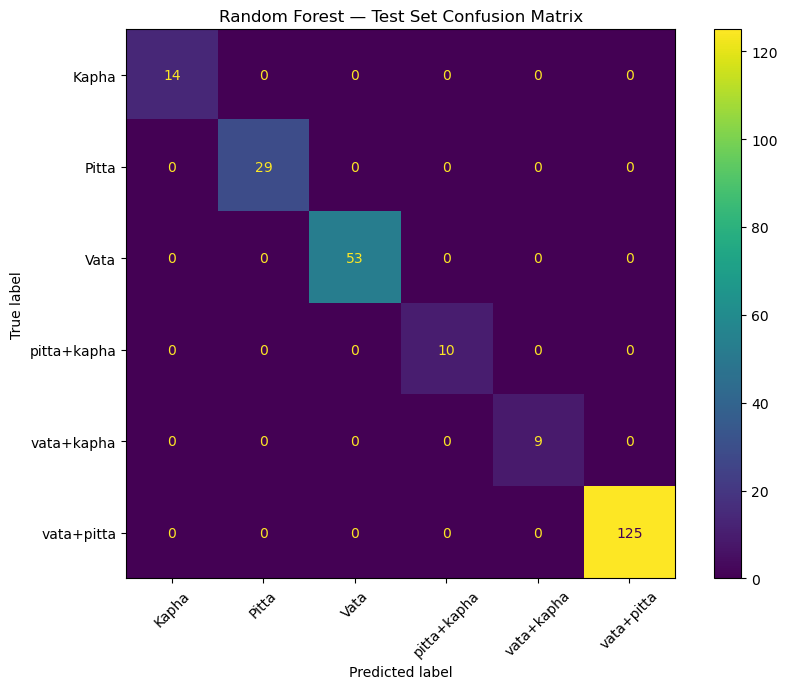

In [50]:
labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
).plot(ax=ax, xticks_rotation=45, values_format="d")

ax.set_title("Random Forest — Test Set Confusion Matrix")
plt.tight_layout()
plt.show()


## 14. Five-fold stratified cross-validation

Macro F1 is the main comparison/selection metric because the dataset contains multiple classes with unequal frequencies.


In [51]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}

cv_results = cross_validate(
    model_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision_macro"].mean(),
        cv_results["test_recall_macro"].mean(),
        cv_results["test_f1_macro"].mean(),
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision_macro"].std(),
        cv_results["test_recall_macro"].std(),
        cv_results["test_f1_macro"].std(),
    ],
})

display(
    cv_summary.style.format({
        "Mean": "{:.4f}",
        "Std": "{:.4f}",
    })
)


,Metric,Mean,Std
0,Accuracy,1.0000,0.0000
1,Macro Precision,1.0000,0.0000
2,Macro Recall,1.0000,0.0000
3,Macro F1,1.0000,0.0000


## 15. Cross-validation results by fold


In [52]:
fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": cv_results["test_accuracy"],
    "Macro Precision": cv_results["test_precision_macro"],
    "Macro Recall": cv_results["test_recall_macro"],
    "Macro F1": cv_results["test_f1_macro"],
})

display(
    fold_results.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
    })
)


,Fold,Accuracy,Macro Precision,Macro Recall,Macro F1
0,1,1.0000,1.0000,1.0000,1.0000
1,2,1.0000,1.0000,1.0000,1.0000
2,3,1.0000,1.0000,1.0000,1.0000
3,4,1.0000,1.0000,1.0000,1.0000
4,5,1.0000,1.0000,1.0000,1.0000


## 16. Random Forest feature importance

This is useful for the project report and does not change the model.


In [53]:
fitted_preprocessor = model_pipeline.named_steps["preprocessor"]
fitted_rf = model_pipeline.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": fitted_rf.feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importance.head(20))


,feature,importance
45,"categorical__Teeth and gums_Big, White, Strong...",0.055568
30,"categorical__Eyes_Big, round, beautiful, glowi...",0.045175
3,categorical__Body Weight_Heavy - difficulties ...,0.038408
5,categorical__Body Weight_Moderate - no difficu...,0.034670
14,"categorical__Complexion_White, pale, tans easily",0.034543
49,"categorical__Lips_Lips are soft, medium-sized",0.029014
51,"categorical__Nails_Dry, Rough, Brittle, Break",0.026151
9,"categorical__Bone Structure_Large, broad shoul...",0.025913
0,categorical__Body Size_Large,0.025876
25,"categorical__Appearance of Hair_Straight, oily",0.023461


## 17. Train final model on all available data

After evaluation, train the same pipeline configuration on all deduplicated records. The saved pipeline contains both One-Hot Encoding and Random Forest.


In [54]:
final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "categorical",
                        OneHotEncoder(handle_unknown="ignore"),
                        categorical_features,
                    )
                ],
                remainder="drop",
            ),
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1,
            ),
        ),
    ]
)

final_model.fit(X, y)
print("Final model trained on all available data.")


Final model trained on all available data.


## 18. Save the trained model


In [55]:
joblib.dump(final_model, MODEL_PATH)
print("Saved:", MODEL_PATH)
print("Exists:", MODEL_PATH.exists())


Saved: D:\prakruti-chatbot\ml\models\prakruti_random_forest.pkl
Exists: True


## 19. Save model metadata


In [56]:
metadata = {
    "model_name": "RandomForestClassifier",
    "target_column": TARGET_COLUMN,
    "problem_type": "multiclass_classification",
    "classes": sorted(y.unique().tolist()),
    "n_classes": int(y.nunique()),
    "n_features_raw": int(X.shape[1]),
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "n_estimators": 300,
    "class_weight": "balanced",
    "random_state": 42,
    "test_size": 0.20,
    "cv_folds": 5,
    "duplicate_rows_removed": int(rows_before - rows_after),
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "cv_macro_f1_mean": float(cv_results["test_f1_macro"].mean()),
    "cv_macro_f1_std": float(cv_results["test_f1_macro"].std()),
    "python_version": sys.version,
    "platform": platform.platform(),
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("Saved:", METADATA_PATH)


Saved: D:\prakruti-chatbot\ml\models\prakruti_random_forest_metadata.json


## 20. Reload and verify the saved model


In [57]:
loaded_model = joblib.load(MODEL_PATH)

loaded_predictions = loaded_model.predict(X_test)
loaded_accuracy = accuracy_score(y_test, loaded_predictions)

print("Loaded object:", type(loaded_model).__name__)
print(f"Reloaded model accuracy on the test set: {loaded_accuracy:.4f}")

assert np.array_equal(y_pred, loaded_predictions)
print("Model reload verification: PASSED")


Loaded object: Pipeline
Reloaded model accuracy on the test set: 1.0000
Model reload verification: PASSED


## 21. Example prediction


In [58]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)[0]

print("Predicted Dosha:", prediction)
print("Actual Dosha:   ", y_test.iloc[0])


Predicted Dosha: Pitta
Actual Dosha:    Pitta


## 22. Optional class probabilities

These are Random Forest class probabilities only. **Do not display them as Vata/Pitta/Kapha percentages.**


In [59]:
probabilities = loaded_model.predict_proba(sample)[0]

probability_table = pd.DataFrame({
    "Dosha Class": loaded_model.classes_,
    "Model Probability": probabilities,
}).sort_values("Model Probability", ascending=False)

display(
    probability_table.style.format({
        "Model Probability": "{:.4f}"
    })
)


,Dosha Class,Model Probability
1,Pitta,1.0000
0,Kapha,0.0000
2,Vata,0.0000
3,pitta+kapha,0.0000
4,vata+kapha,0.0000
5,vata+pitta,0.0000


## 23. Final summary


In [60]:
print("=" * 60)
print("RANDOM FOREST TRAINING COMPLETE")
print("=" * 60)
print(f"Rows used:            {len(df)}")
print(f"Input features:       {X.shape[1]}")
print(f"Target:               {TARGET_COLUMN}")
print(f"Classes:              {y.nunique()}")
print(f"Test Macro F1:        {test_metrics['Macro F1']:.4f}")
print(f"5-Fold CV Macro F1:   {cv_results['test_f1_macro'].mean():.4f}")
print(f"Model:                {MODEL_PATH}")
print(f"Metadata:             {METADATA_PATH}")
print("=" * 60)


RANDOM FOREST TRAINING COMPLETE
Rows used:            1199
Input features:       29
Target:               Dosha
Classes:              6
Test Macro F1:        1.0000
5-Fold CV Macro F1:   1.0000
Model:                D:\prakruti-chatbot\ml\models\prakruti_random_forest.pkl
Metadata:             D:\prakruti-chatbot\ml\models\prakruti_random_forest_metadata.json
